# This Notebook Deals with Gene Trend Analysis

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ["OPENBLAS_NUM_THREADS"] = "4"  # or a lower number like 2, 4, or 8

import sys, re, torch, time, PINN, palantir
import numpy as np
import pandas as pd
import scanpy as sc
from tqdm.auto import tqdm
# PINN
from PINN import reader, models, pl, tl
# plot
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages

# os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")
# os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")
os.chdir("/home/wz369/rds/hpc-work/PINN_dynamics")

In [2]:
adata = sc.read_h5ad(f"data/tom_pos.h5ad")

In [4]:


# load PINT params
adata.obsm['g'] = np.load('results/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/g.npy')
adata.obsm['v_sum'] = np.load('results/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/v_sum.npy')
adata.obsm['v_norm'] = np.load('results/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/v_norm.npy')
adata.obsm['nabla_v'] = np.load('results/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/nabla_v.npy')
adata.obsm['D'] = np.load('results/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/D.npy')

adata

FileNotFoundError: [Errno 2] No such file or directory: 'results/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/g.npy'

In [3]:
terminal_cells = adata.obs[['anno_man','dpt_pseudotime']].copy()
terminal_cells = terminal_cells.sort_values("dpt_pseudotime", ascending=False)
terminal_cells = terminal_cells.drop_duplicates(['anno_man'], keep='first')

terminal_cells['anno_man'] = terminal_cells['anno_man'].astype('object')
terminal_cells

,anno_man,dpt_pseudotime
7w11w_SITTC3_TTCGGTCTCAGGGTAG-1-10x,Ery,0.338419
2w4w_SITTC4_ATACCGATCTCCCAAC-1-10x,Ly,0.212603
16w_SITTE12_AGGGTCCTCTTAGGAC-1-10x,Neu,0.166928
16w_SITTD12_AGTAGTCAGTGTGTTC-1-10x,Mono/DC prog,0.162837
16w_SITTD12_ACGGTTAAGTAAACTG-1-10x,Bas/MC prog,0.137405
7w11w_SITTD3_ACTGTGATCTTGGGCG-1-10x,Int prog,0.117527
5mo_SIGAD9_CCCTAACGTTCTCACC-1-10x,Meg,0.101988
9mo_SIGAE3_TTTATGCAGTTTGTCG-1-10x,Eos,0.098990
16w_SITTE12_CATGGATAGTAAATGC-1-10x,HSC,0.049334


In [4]:
# remove intermediately differentiated cells
inter_cells = ['Int prog', "HSC", "Eos"]
terminal_cells.query("`anno_man` not in @inter_cells", inplace=True)

# Assign root cell
root_cb = adata.obs.query("`timepoint_tx_days`==7").dpt_pseudotime.idxmin()


all_cellstate = terminal_cells.copy()
all_cellstate.loc[root_cb , 'anno_man'] = 'root'

(<Figure size 600x600 with 1 Axes>, <Axes: >)

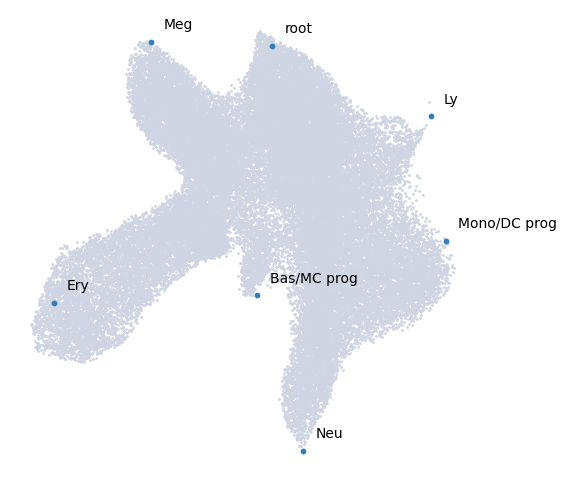

In [5]:
palantir.plot.highlight_cells_on_umap(adata, all_cellstate['anno_man'])

# compute gene trends

In [6]:
ms_data = palantir.utils.determine_multiscale_space(adata, )

In [7]:
start_cell = root_cb

pr_res = palantir.core.run_palantir(
    adata, start_cell, knn=30, num_waypoints=500, terminal_states=terminal_cells['anno_man']
)

masks = palantir.presults.select_branch_cells(adata, q=.001, eps=.02)

Sampling and flocking waypoints...
Time for determining waypoints: 0.014452409744262696 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...


OpenBLAS warning: precompiled NUM_THREADS exceeded, adding auxiliary array for thread metadata.
To avoid this warning, please rebuild your copy of OpenBLAS with a larger NUM_THREADS setting
or set the environment variable OPENBLAS_NUM_THREADS to 128 or lower


Time for shortest paths: 1.8191561460494996 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9977
Correlation at iteration 2: 0.9999
Correlation at iteration 3: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


Time for shortest paths: 2.618905750910441 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9977
Correlation at iteration 2: 0.9999
Correlation at iteration 3: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...


In [9]:
adata.obsm['branch_masks']

,Bas/MC prog,Mono/DC prog,Neu,Ly,Meg,Ery
9mo_SIGAE3_AAACCCAAGACCTCAT-1-10x,False,False,False,False,False,False
9mo_SIGAE3_AAACCCAGTCTCGGGT-1-10x,False,False,True,False,False,False
9mo_SIGAE3_AAACGAAAGACATGCG-1-10x,False,False,True,False,False,False
9mo_SIGAE3_AAACGAAAGAGGTCAC-1-10x,False,False,True,False,False,False
9mo_SIGAE3_AAACGAACAATAGAGT-1-10x,False,False,True,False,False,False
...,...,...,...,...,...,...
1281-SS2,True,True,True,True,True,True
1282-SS2,False,False,False,True,False,False
1283-SS2,True,True,True,True,False,False
1285-SS2,False,False,False,False,False,False


In [10]:
adata.obsm['branch_masks'].to_csv("data/tom_pos_palantir_branch_mask.csv", index=True)

In [19]:
from importlib import reload
reload(sc)
reload(ad)

<module 'anndata' from '/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/anndata/__init__.py'>

In [18]:
import anndata as ad

In [ ]:
param_df = {}
param_df['Meg'] = pd.read_csv("data/HSCP_PD_params/clu7/table_all_parameters_clu_7.csv", index_col=0)
param_df['Ery'] = pd.read_csv("data/HSCP_PD_params/clu10/table_all_parameters_clu_10.csv", index_col=0)
param_df['Neu'] = pd.read_csv("data/HSCP_PD_params/clu11/table_all_parameters_clu_11.csv", index_col=0)

branch_df = adata.obsm['branch_masks'].copy()
for lineage in ['Neu','Ery','Meg']:
    branch_df[lineage] = branch_df.index.isin(param_df[lineage].index)

adata.obsm['branch_masks'] = branch_df

In [21]:
adata.raw = None
adata.write_h5ad("data/tom_pos_palantir_Jun4.h5ad")

In [11]:
adata_raw = adata.raw.to_adata()

In [ ]:
for key in ['g', 'v_sum', 'v_norm', 'nabla_v', 'D', 'DM_EigenVectors_multiscaled', 'palantir_fate_probabilities', 'branch_masks']:
    adata_raw.obsm[key] = adata.obsm[key].copy()


for key in [ 'DM_Kernel', 'DM_Similarity', 'DM_connectivities', 'DM_distances']:
    adata_raw.obsp[key] = adata.obsp[key].copy()

adata_raw.obs['palantir_pseudotime'] = adata.obs['palantir_pseudotime'].copy()


In [ ]:
# impute_x = palantir.utils.run_magic_imputation(adata_raw)
# np.save("data/tom_pos_raw_impute_X.npy", impute_x)
impute_x_reload = np.load("data/tom_pos_raw_impute_X.npy", allow_pickle=True).item()
adata_raw.layers['MAGIC_imputed_data'] = impute_x_reload

In [40]:
adata_raw.write("data/tom_pos_raw_palantir_Jun4.h5ad")

In [42]:
adata_raw

AnnData object with n_obs × n_vars = 49390 × 22035
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', '

# plot gene trend

In [12]:
adata_raw = sc.read_h5ad("data/tom_pos_raw_palantir_Jun4.h5ad")

gene_trends = palantir.presults.compute_gene_trends(
    adata_raw,
    expression_key="MAGIC_imputed_data",
)

KeyError: 'MAGIC_imputed_data'

In [43]:
adata_neu = adata_raw[adata_raw.obsm['branch_masks']['Neu']].copy()

In [44]:
adata_neu

AnnData object with n_obs × n_vars = 23442 × 22035
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', '

In [94]:
np.isnan(adata_neu.obsm['v_norm'].T).any()

False

In [100]:
from importlib import reload
reload(tl)

<module 'PINN.functions' from '/ssd/users/Wergillius/Project/PINN_dynamics/PINN/functions/__init__.py'>

In [101]:
pint_project = tl.aggregate_params_by_pseudotime(adata_neu, adata_neu.obsm['v_norm'].T, 
                                        param_names='v', timepoints=None, 
                                        pseudotime_key='palantir_pseudotime',
                                        nbins=100, return_y=True)


pint_g = tl.aggregate_params_by_pseudotime(adata_neu, adata_neu.obsm['g'].T, 
                                        param_names='g', timepoints=None, 
                                        pseudotime_key='palantir_pseudotime',
                                        nbins=100, return_y=True)

In [46]:
TFgroup1 = ["Cebpe", "Clec4a2", "Cst7", "Elane", "Fcgr3", "Prtn3", "S100a8", "Wfdc21"]

TFgroup2 = ["Aff3", "Dach1", "Hhex", "Hmga2", "Ikzf2", "Irf8", "Pou2f2", "Sox4", "Ssbp2"]
    
TFgroup3 = ["Cebpe", "Chd7", "Cited4", "Gfi1", "Med21", "Mix", ]

In [47]:
adata.raw.to_adata()

AnnData object with n_obs × n_vars = 49390 × 22035
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', '

In [48]:
adata_neu.obs.palantir_pseudotime.max()

0.9206044730718377

In [49]:
# Plot scaled gene expression trends for TFgroup1 along pseudotime in the Neu branch

def plot_gene_trends(adata, gene_list, pseudotime_key='palantir_pseudotime', n_bins=100, PINN_params=None, para_name=None):
    """
    Plot gene trends for a list of genes along pseudotime.
    
    Parameters:
    - adata: AnnData object containing the data.
    - gene_list: List of genes to plot.
    - pseudotime_key: Key in adata.obs that contains pseudotime values.
    - n_bins: Number of bins for pseudotime.
    """
    # Ensure the gene list is in the correct format
    
    overlap_genes = set(gene_list).intersection(adata.var_names)
    print("gene not found :", set(gene_list) - overlap_genes)
    gene_trends_neu = adata.varm['gene_trends_Neu'].loc[list(overlap_genes)]

    fig = plt.figure(figsize=(8, 5))
    ax = fig.gca()

    x = gene_trends_neu.columns.astype(float)  # Convert column names to float for plotting
    # Plot gene trends
    for gene in gene_trends_neu.index:
        ax.plot(x, gene_trends_neu.loc[gene], label=gene)

    # Set x-ticks to only 5 evenly spaced ticks
    xticks = np.linspace(0, len(gene_trends_neu.columns) - 1, 5, dtype=int)


    if PINN_params is not None and para_name is not None:
        # Plot pint_project[3] on a secondary y-axis
        ax2 = ax.twinx()
        # Align x for pint_project[3] (length 99) to gene_trends_neu columns (length N)
        x_pint = np.linspace(0, 0.92, 99)

        ax2.plot(x_pint, PINN_params, color='black', linestyle='--', label=para_name)
        ax2.set_ylabel("PINT v_norm")
        lines2, labels2 = ax2.get_legend_handles_labels()
    else:
        ax2 = None
        lines2, labels2 = [], []

    # # Legends
    lines1, labels1 = ax.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, bbox_to_anchor=(1.15, 1), loc='upper left')

    # ax.set_xticks(np.linspace(0,1, 5))
    ax.set_xlabel("Pseudotime")
    ax.set_ylabel("Scaled gene expression")

    plt.title("Gene trends for Neutrophil genes along pseudotime (Neu branch)")
    plt.tight_layout()
    plt.show()

    return fig, ax, ax2

gene not found : set()


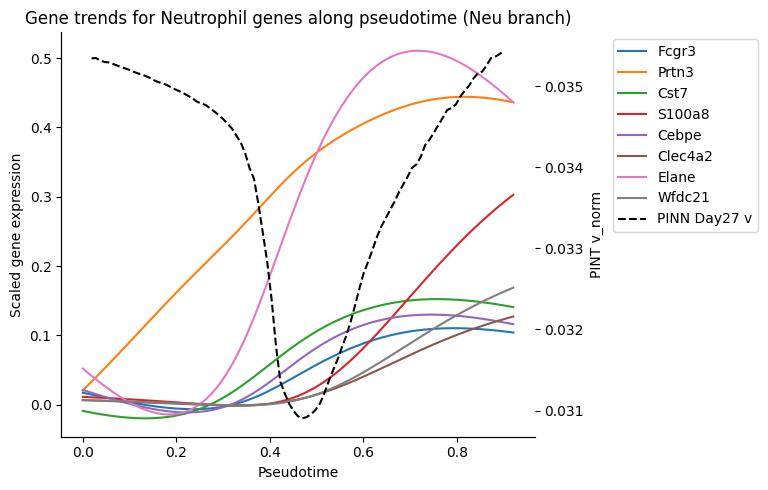

(<Figure size 800x500 with 2 Axes>,
 <Axes: xlabel='Pseudotime', ylabel='Scaled gene expression'>,
 <Axes: title={'center': 'Gene trends for Neutrophil genes along pseudotime (Neu branch)'}, ylabel='PINT v_norm'>)

In [51]:
plot_gene_trends(adata_raw, TFgroup1,
                 PINN_params=pint_project[3], para_name='PINN Day27 v')

gene not found : set()


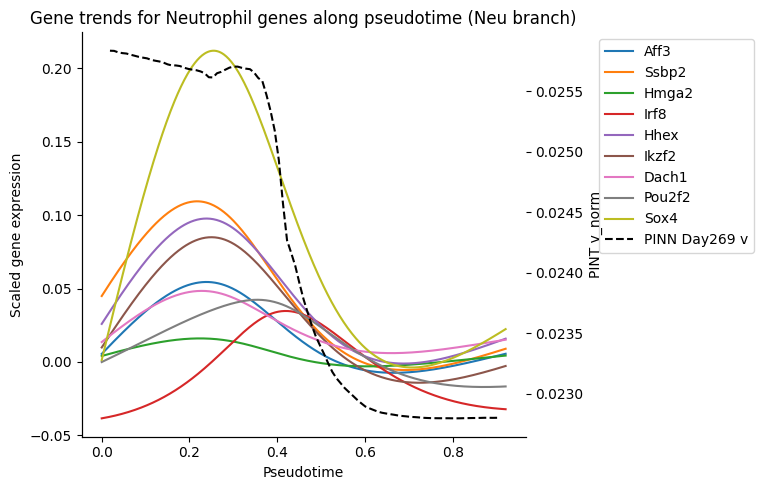

(<Figure size 800x500 with 2 Axes>,
 <Axes: xlabel='Pseudotime', ylabel='Scaled gene expression'>,
 <Axes: title={'center': 'Gene trends for Neutrophil genes along pseudotime (Neu branch)'}, ylabel='PINT v_norm'>)

In [54]:
plot_gene_trends(adata_raw, TFgroup2,
                 PINN_params=pint_project[8], para_name='PINN Day269 v')

gene not found : {'Mix'}


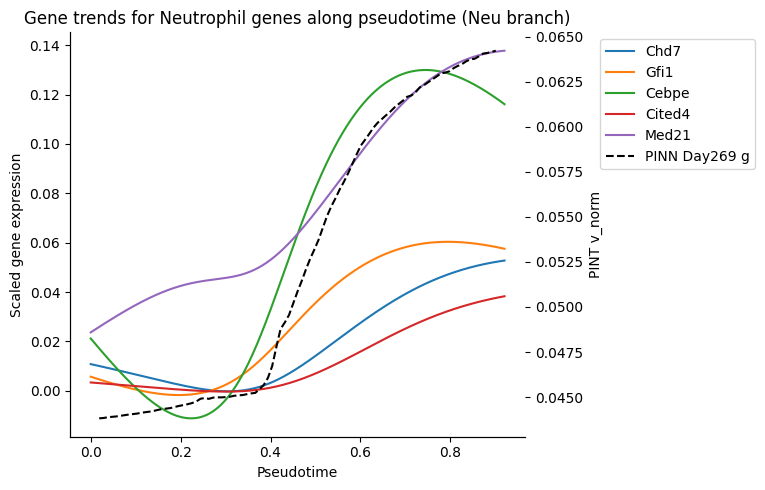

(<Figure size 800x500 with 2 Axes>,
 <Axes: xlabel='Pseudotime', ylabel='Scaled gene expression'>,
 <Axes: title={'center': 'Gene trends for Neutrophil genes along pseudotime (Neu branch)'}, ylabel='PINT v_norm'>)

In [58]:
plot_gene_trends(adata_raw, TFgroup3,
                 PINN_params=pint_g[8], para_name='PINN Day269 g')

gene not found : {'Hmga2', 'Hhex'}


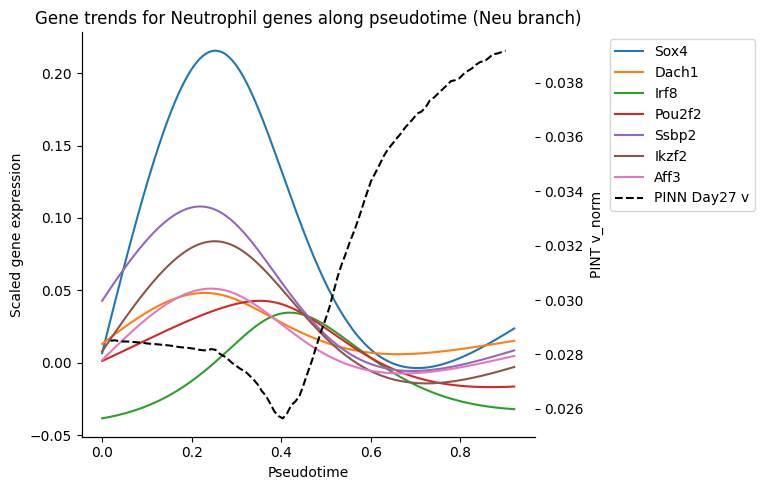

(<Figure size 800x500 with 2 Axes>,
 <Axes: xlabel='Pseudotime', ylabel='Scaled gene expression'>,
 <Axes: title={'center': 'Gene trends for Neutrophil genes along pseudotime (Neu branch)'}, ylabel='PINT v_norm'>)

In [72]:
plot_gene_trends(adata, TFgroup2,
                 PINN_params=pint_project[1], para_name='PINN Day27 v')

In [16]:
plot_gene_trends(adata, TFgroup2,
                 PINN_params=pint_project[8], para_name='PINN Day269 v')

NameError: name 'plot_gene_trends' is not defined

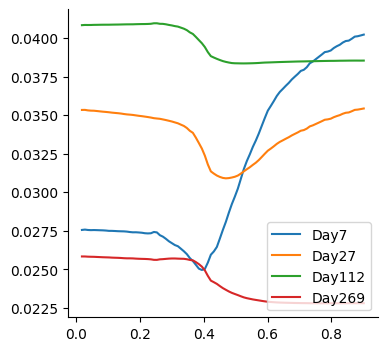

In [42]:
plt.plot(x_pint, pint_project[0], label='Day7')
plt.plot(x_pint, pint_project[3], label='Day27')
plt.plot(x_pint, pint_project[6], label='Day112')
plt.plot(x_pint, pint_project[8], label='Day269')
plt.legend(loc='lower right')

# denovo

Firstly only look at the TFs

In [ ]:

df_motifs_mgi = pd.read_csv("data/mouse_geneset/motifs-v9-nr.mgi-m0.001-o0.0.tbl", sep='\t')
mouse_TFs = "data/mouse_geneset/mouse_TFs.txt"
mm_tfs = df_motifs_mgi.gene_name.unique()
with open(mouse_TFs, 'wt') as f:
    f.write('\n'.join(mm_tfs) + '\n')
len(mm_tfs)

/tmp/ipykernel_3394482/1798349961.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_motifs_mgi = pd.read_csv("data/mouse_geneset/motifs-v9-nr.mgi-m0.001-o0.0.tbl", sep='\t')


1721

In [66]:
mm_tf_found = set(mm_tfs).intersection(adata_raw.var_names)
print(len(mm_tf_found), "mouse TFs found in adata_raw")

1490 mouse TFs found in adata_raw



1. Correlation Analysis
For each gene, compute the correlation (e.g., Pearson or Spearman) between its trend and the parameter curve along pseudotime.

2. Multiple Testing Correction
Apply FDR correction to p-values to identify significantly correlated genes.

3. Clustering by Curve Shape
Cluster the significantly correlated genes by their trend curves (e.g., using hierarchical clustering or k-means).

In [ ]:
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.interpolate import interp1d

def subsample_gene_trends(gene_trends, gt_x, target_x):
    """
    Interpolates gene trends to match the target pseudotime bins.
    gene_trends: DataFrame (genes x pseudotime bins)
    gt_x: array-like, original pseudotime positions of gene trends
    target_x: array-like, target pseudotime positions (e.g., param_curve bins)
    Returns: DataFrame (genes x target pseudotime bins)
    """
    interpolated = []
    TF_index = []
    for gene in gene_trends.index:
        # # skip genes not in the mouse TF list
        # if gene not in mm_tf_found:
        #     continue
        # Interpolate the gene trend to the target pseudotime bins
        f = interp1d(gt_x, gene_trends.loc[gene], kind='linear', fill_value='extrapolate')
        interpolated.append(f(target_x))
        TF_index.append(gene)
    return pd.DataFrame(interpolated, index=TF_index, columns=target_x)



def correlate_gene_trends(gene_trends, param_curve):
    """
    gene_trends: DataFrame (genes x pseudotime bins)
    param_curve: 1D array (same length as pseudotime bins)
    Returns: DataFrame with correlation and p-value for each gene
    """
    results = []
    for gene in gene_trends.index:
        y = gene_trends.loc[gene].values
        corr, pval = stats.pearsonr(y, param_curve)
        results.append({'gene': gene, 'corr': corr, 'pval': pval})
    return pd.DataFrame(results).set_index('gene')


def significant_genes(corr_df, alpha=0.05):
    """
    Apply FDR correction to p-values to identify significantly correlated genes.
    """
    corr_df['fdr'] = multipletests(corr_df['pval'], method='fdr_bh')[1]
    return corr_df[corr_df['fdr'] < alpha].sort_values('corr', ascending=False)


def cluster_gene_trends(gene_trends, n_clusters=3):
    """
    Cluster the significantly correlated genes by their trend curves (e.g., using hierarchical clustering or k-means).
    """
    scaler = StandardScaler()
    X = scaler.fit_transform(gene_trends)
    clustering = AgglomerativeClustering(n_clusters=n_clusters)
    labels = clustering.fit_predict(X)
    return labels




Plot the parameter curve and gene trends (mean ± std for each cluster) on the same pseudotime axis.

In [71]:
def plot_param_and_clusters(gene_trends, param_curve, cluster_labels, pseudotime_bins):
    
    clusters = np.unique(cluster_labels)
    plt.figure(figsize=(10,6))
    # Plot parameter curve
    plt.plot(pseudotime_bins, param_curve, color='black', lw=2, label='Parameter')
    # Plot mean ± std for each cluster
    for c in clusters:
        idx = cluster_labels == c
        mean_trend = gene_trends[idx].mean(axis=0)
        std_trend = gene_trends[idx].std(axis=0)
        plt.plot(pseudotime_bins, mean_trend, label=f'Cluster {c+1}')
        plt.fill_between(pseudotime_bins, mean_trend-std_trend, mean_trend+std_trend, alpha=0.2)
    plt.xlabel('Scaled Pseudotime')
    plt.ylabel('Expression / Parameter')
    plt.legend()
    plt.tight_layout()
    plt.show()

Get gene trend of TFs and sub sample to 99 bins

In [103]:
gene_trends_neu = adata_neu.varm['gene_trends_Neu']
gt_x = gene_trends_neu.columns.astype(float)  # Convert column names to float for plotting

target_x = np.linspace(0, gt_x.max(), 99)  # Assuming this is the target pseudotime bins
sub_gene_trend_TFs = subsample_gene_trends(gene_trends_neu, gt_x, target_x)

In [108]:
sub_gene_trend_TFs

,0.000000,0.009394,0.018788,0.028182,0.037576,0.046970,0.056364,0.065757,0.075151,0.084545,...,0.836059,0.845453,0.854847,0.864241,0.873635,0.883029,0.892423,0.901817,0.911211,0.920604
Sox17,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mybl1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Tcf24,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Prdm14,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Msc,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Gpam,-0.000288,-0.000267,-0.000246,-0.000224,-0.000203,-0.000182,-0.000161,-0.000140,-0.000119,-0.000098,...,0.000023,2.824692e-05,0.000034,0.000039,0.000045,0.000050,0.000055,0.000061,0.000066,0.000072
Tcf7l2,0.020002,0.020920,0.021811,0.022670,0.023496,0.024284,0.025031,0.025735,0.026392,0.026997,...,0.006096,6.485932e-03,0.006871,0.007251,0.007626,0.007995,0.008358,0.008715,0.009067,0.009411
Vax1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Nanos1,-0.000264,-0.000249,-0.000235,-0.000220,-0.000205,-0.000190,-0.000175,-0.000160,-0.000145,-0.000130,...,-0.000004,-2.805193e-07,0.000004,0.000008,0.000013,0.000017,0.000021,0.000026,0.000030,0.000034


In [ ]:
# Assume gene_trends_neu is a DataFrame (genes x pseudotime bins)
param_curve = pint_project[8]  # Example parameter
pseudotime_bins = np.linspace(0, gt_x.max(), param_curve.shape[0])

corr_df = correlate_gene_trends(sub_gene_trend_TFs, param_curve)
sig_genes = significant_genes(corr_df)
sig_trends = gene_trends_neu.loc[sig_genes.index]

/tmp/ipykernel_3394482/130326999.py:38: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, pval = stats.pearsonr(y, param_curve)


ValueError: Found array with 0 sample(s) (shape=(0, 500)) while a minimum of 1 is required by StandardScaler.

In [107]:
corr_df

,corr,pval,fdr
gene,,,
Sox17,NaN,NaN,NaN
Mybl1,NaN,NaN,NaN
Tcf24,NaN,NaN,NaN
Prdm14,NaN,NaN,NaN
Msc,NaN,NaN,NaN
...,...,...,...
Gpam,0.250464,1.240426e-02,NaN
Tcf7l2,0.844453,4.774681e-28,NaN
Vax1,NaN,NaN,NaN


In [ ]:
labels = cluster_gene_trends(sig_trends.values, n_clusters=3)
plot_param_and_clusters(sig_trends.values, param_curve, labels, pseudotime_bins)